<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


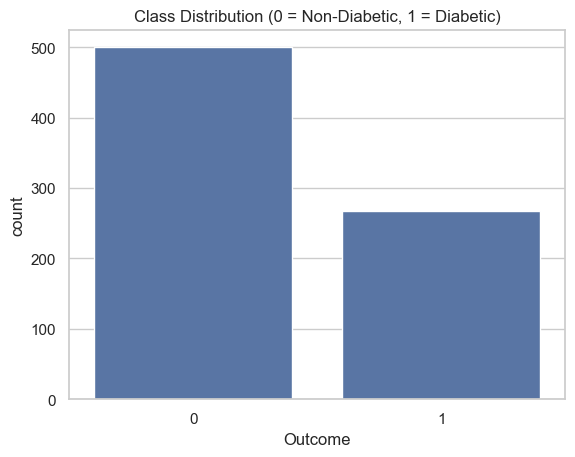

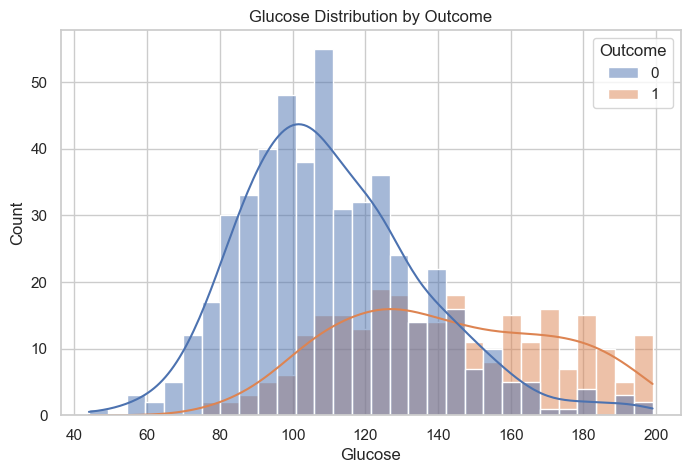

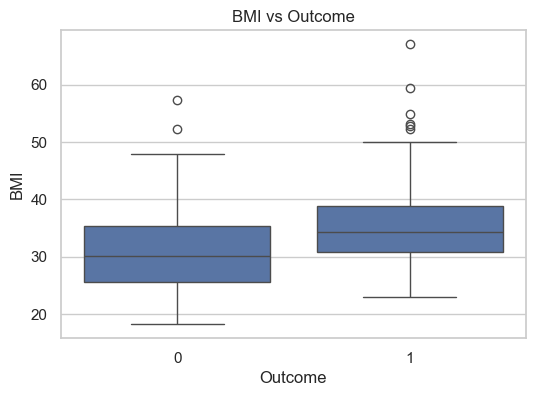

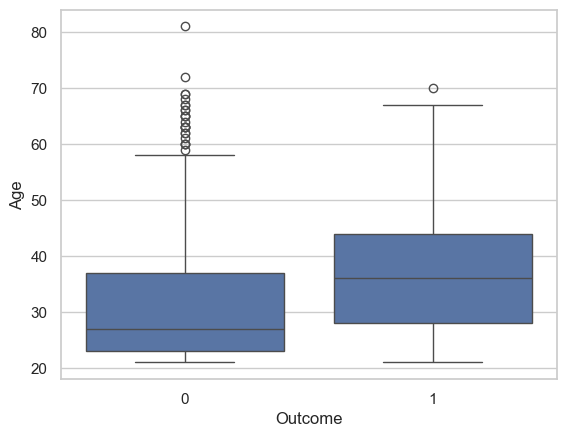

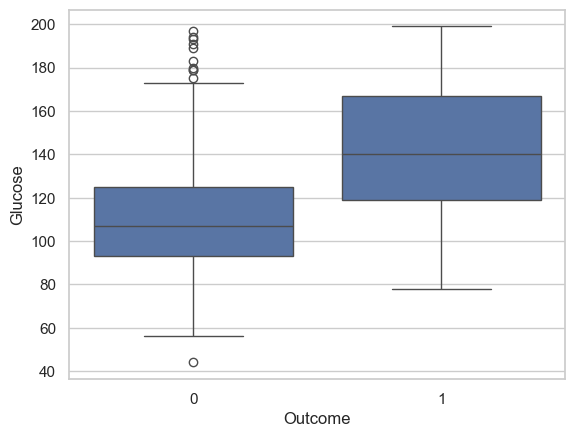

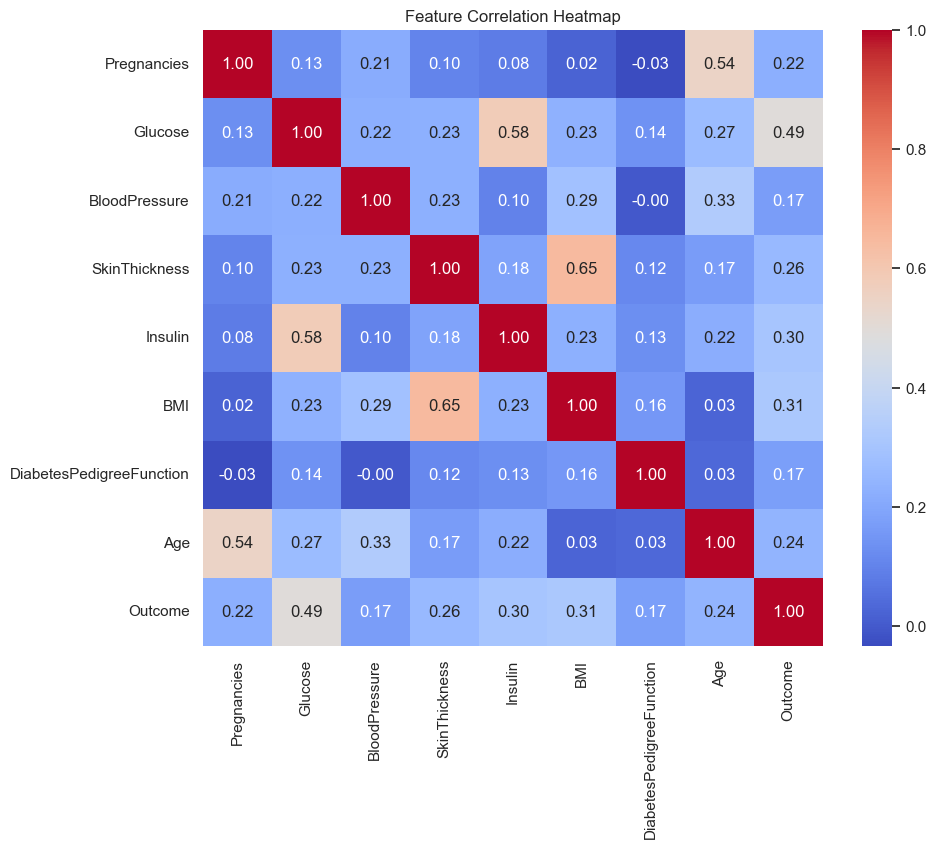

              precision    recall  f1-score   support

           0       0.75      0.80      0.77       100
           1       0.57      0.50      0.53        54

    accuracy                           0.69       154
   macro avg       0.66      0.65      0.65       154
weighted avg       0.69      0.69      0.69       154

ROC-AUC: 0.8142592592592592


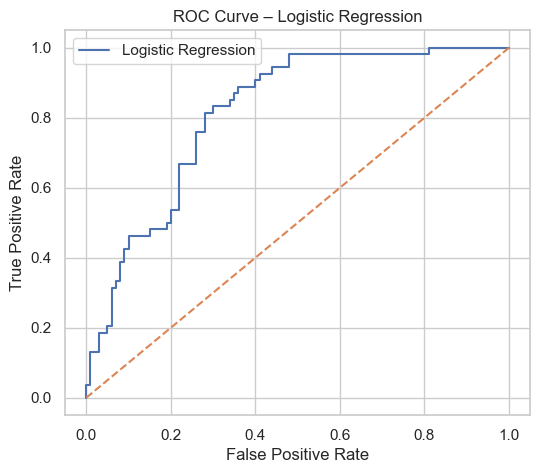

              precision    recall  f1-score   support

           0       0.79      0.76      0.78       100
           1       0.59      0.63      0.61        54

    accuracy                           0.71       154
   macro avg       0.69      0.69      0.69       154
weighted avg       0.72      0.71      0.72       154

ROC-AUC: 0.8112962962962963


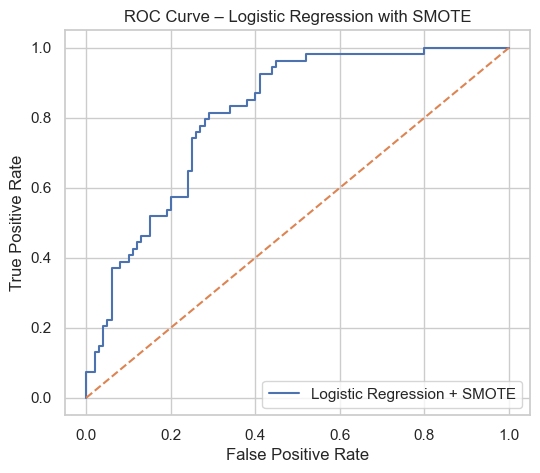

              precision    recall  f1-score   support

           0       0.77      0.81      0.79       100
           1       0.61      0.56      0.58        54

    accuracy                           0.72       154
   macro avg       0.69      0.68      0.69       154
weighted avg       0.72      0.72      0.72       154

ROC-AUC: 0.7583333333333333


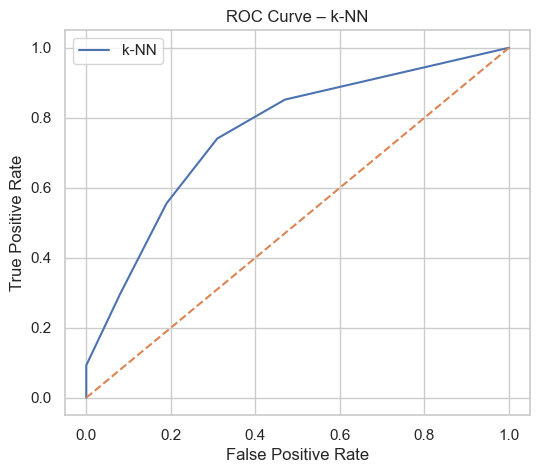

              precision    recall  f1-score   support

           0       0.78      0.69      0.73       100
           1       0.53      0.65      0.58        54

    accuracy                           0.68       154
   macro avg       0.66      0.67      0.66       154
weighted avg       0.70      0.68      0.68       154

ROC-AUC: 0.7479629629629629


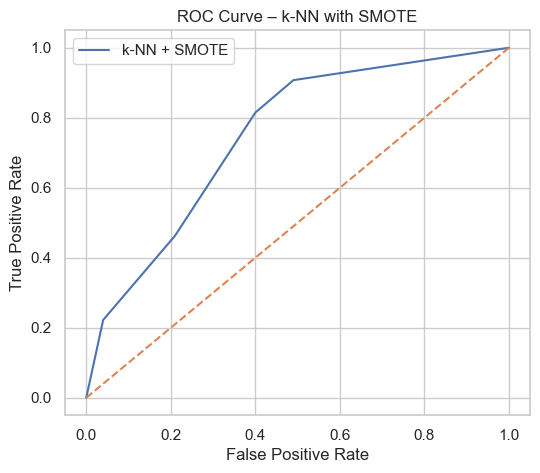

              precision    recall  f1-score   support

           0       0.77      0.84      0.80       100
           1       0.64      0.54      0.59        54

    accuracy                           0.73       154
   macro avg       0.71      0.69      0.69       154
weighted avg       0.73      0.73      0.73       154

ROC-AUC: 0.7947222222222223


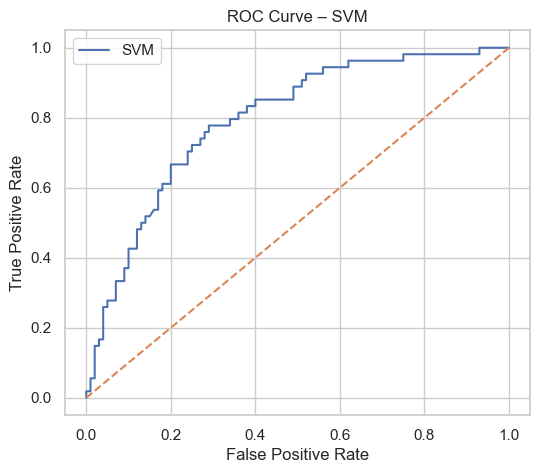

              precision    recall  f1-score   support

           0       0.81      0.78      0.80       100
           1       0.62      0.67      0.64        54

    accuracy                           0.74       154
   macro avg       0.72      0.72      0.72       154
weighted avg       0.75      0.74      0.74       154

ROC-AUC: 0.8112962962962963


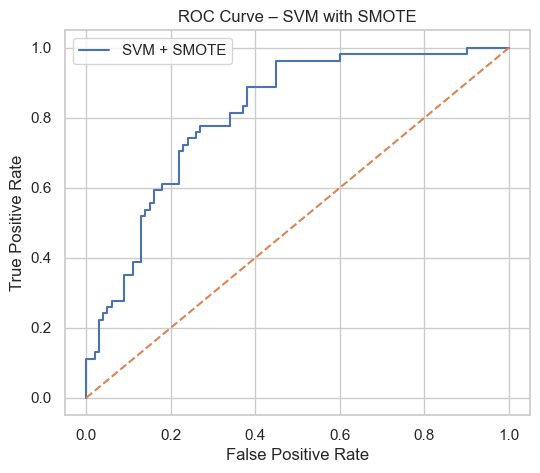

              precision    recall  f1-score   support

           0       0.76      0.83      0.79       100
           1       0.62      0.52      0.57        54

    accuracy                           0.72       154
   macro avg       0.69      0.67      0.68       154
weighted avg       0.71      0.72      0.71       154

ROC-AUC: 0.8148148148148149


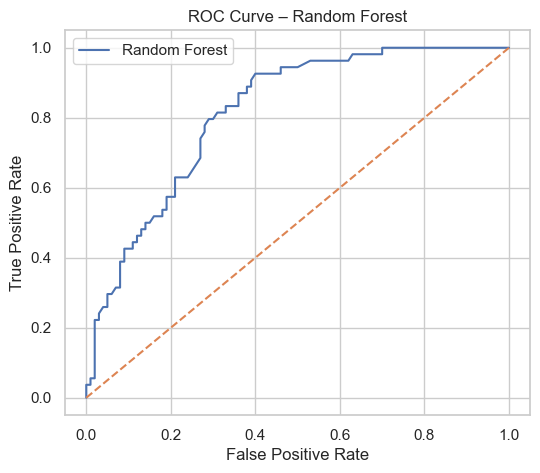

Glucose                     0.225070
Insulin                     0.171215
BMI                         0.140526
DiabetesPedigreeFunction    0.109165
Age                         0.109067
SkinThickness               0.104886
BloodPressure               0.075342
Pregnancies                 0.064728
dtype: float64


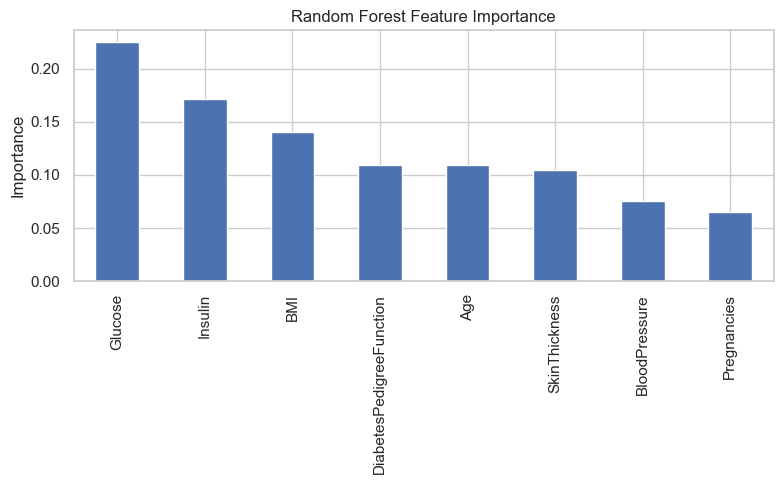

              precision    recall  f1-score   support

           0       0.82      0.77      0.79       100
           1       0.62      0.69      0.65        54

    accuracy                           0.74       154
   macro avg       0.72      0.73      0.72       154
weighted avg       0.75      0.74      0.74       154

ROC-AUC: 0.8172222222222223


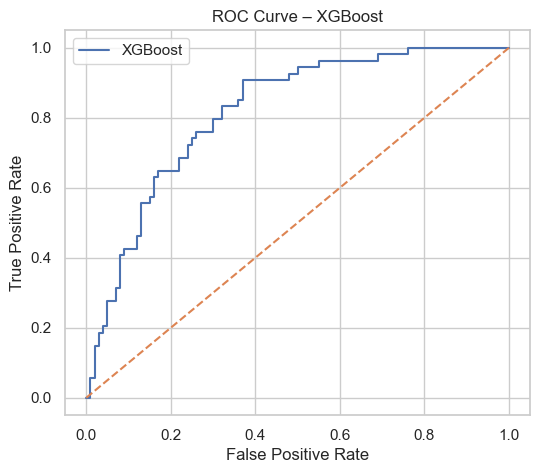

Glucose                     0.247068
BMI                         0.139567
Age                         0.124913
Insulin                     0.123904
DiabetesPedigreeFunction    0.099285
SkinThickness               0.094710
Pregnancies                 0.092494
BloodPressure               0.078059
dtype: float32


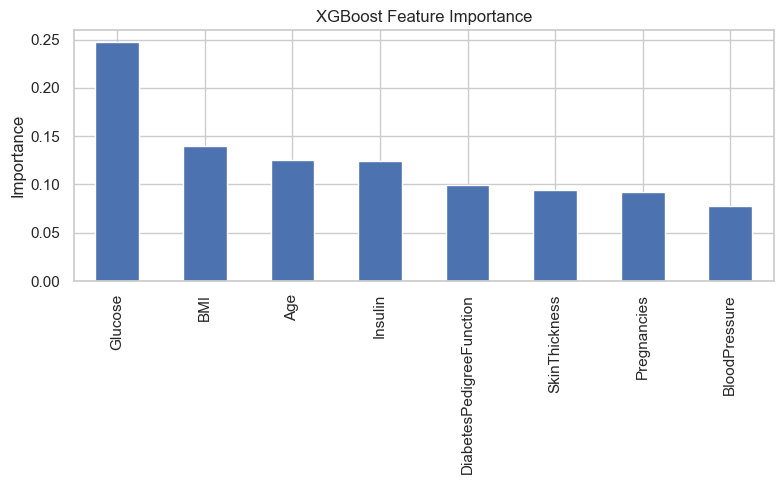

In [8]:
import pandas as pd

df = pd.read_csv("diabetes.csv")
df.head()

df.shape, df.columns

df.info()

df["Outcome"].value_counts()

df.head()

df.describe()

zero_counts = (df == 0).sum()
zero_counts

import numpy as np

cols_with_zero_as_missing = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

df[cols_with_zero_as_missing] = df[cols_with_zero_as_missing].replace(0, np.nan)

df.isna().sum()


import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

sns.countplot(x="Outcome", data=df)
plt.title("Class Distribution (0 = Non-Diabetic, 1 = Diabetic)")
plt.show()

plt.figure(figsize=(8,5))
sns.histplot(data=df, x="Glucose", hue="Outcome", bins=30, kde=True)
plt.title("Glucose Distribution by Outcome")
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(x="Outcome", y="BMI", data=df)
plt.title("BMI vs Outcome")
plt.show()

sns.boxplot(x="Outcome", y="Age", data=df)
plt.show()

sns.boxplot(x="Outcome", y="Glucose", data=df)
plt.show()

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()


X = df.drop("Outcome", axis=1)
y = df["Outcome"]


from sklearn.impute import KNNImputer

knn_imputer = KNNImputer(n_neighbors=5)

X_knn = knn_imputer.fit_transform(X)

# Convert back to DataFrame
X_knn = pd.DataFrame(X_knn, columns=X.columns)

X_knn.isna().sum()

from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

iter_imputer = IterativeImputer(random_state=42)

X_iter = iter_imputer.fit_transform(X)

# Convert back to DataFrame
X_iter = pd.DataFrame(X_iter, columns=X.columns)

X_iter.isna().sum()

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_knn,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled.shape, X_test_scaled.shape

from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(max_iter=1000, random_state=42)

log_reg.fit(X_train_scaled, y_train)

y_pred = log_reg.predict(X_test_scaled)
y_prob = log_reg.predict_proba(X_test_scaled)[:, 1]

from sklearn.metrics import classification_report, roc_auc_score

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label="Logistic Regression")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Logistic Regression")
plt.legend()
plt.show()

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

import pandas as pd

pd.Series(y_train_smote).value_counts()

log_reg_smote = LogisticRegression(max_iter=1000, random_state=42)

log_reg_smote.fit(X_train_smote, y_train_smote)

y_pred_smote = log_reg_smote.predict(X_test_scaled)
y_prob_smote = log_reg_smote.predict_proba(X_test_scaled)[:, 1]

from sklearn.metrics import classification_report, roc_auc_score

print(classification_report(y_test, y_pred_smote))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_smote))

from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, y_prob_smote)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label="Logistic Regression + SMOTE")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Logistic Regression with SMOTE")
plt.legend()
plt.show()

from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)
y_prob_knn = knn.predict_proba(X_test_scaled)[:, 1]

from sklearn.metrics import classification_report, roc_auc_score

print(classification_report(y_test, y_pred_knn))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_knn))

from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, y_prob_knn)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label="k-NN")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – k-NN")
plt.legend()
plt.show()

knn_smote = KNeighborsClassifier(n_neighbors=5)

knn_smote.fit(X_train_smote, y_train_smote)

y_pred_knn_smote = knn_smote.predict(X_test_scaled)
y_prob_knn_smote = knn_smote.predict_proba(X_test_scaled)[:, 1]

from sklearn.metrics import classification_report, roc_auc_score

print(classification_report(y_test, y_pred_knn_smote))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_knn_smote))

from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, y_prob_knn_smote)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label="k-NN + SMOTE")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – k-NN with SMOTE")
plt.legend()
plt.show()

from sklearn.svm import SVC

svm = SVC(kernel="rbf", probability=True, random_state=42)

svm.fit(X_train_scaled, y_train)

y_pred_svm = svm.predict(X_test_scaled)
y_prob_svm = svm.predict_proba(X_test_scaled)[:, 1]

from sklearn.metrics import classification_report, roc_auc_score

print(classification_report(y_test, y_pred_svm))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_svm))

from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, y_prob_svm)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label="SVM")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – SVM")
plt.legend()
plt.show()

svm_smote = SVC(kernel="rbf", probability=True, random_state=42)

svm_smote.fit(X_train_smote, y_train_smote)

y_pred_svm_smote = svm_smote.predict(X_test_scaled)
y_prob_svm_smote = svm_smote.predict_proba(X_test_scaled)[:, 1]

from sklearn.metrics import classification_report, roc_auc_score

print(classification_report(y_test, y_pred_svm_smote))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_svm_smote))

from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, y_prob_svm_smote)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label="SVM + SMOTE")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – SVM with SMOTE")
plt.legend()
plt.show()


from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced"
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))

fpr, tpr, _ = roc_curve(y_test, y_prob_rf)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label="Random Forest")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Random Forest")
plt.legend()
plt.show()

import pandas as pd

importances = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print(importances)

plt.figure(figsize=(8,5))
importances.plot(kind="bar")
plt.title("Random Forest Feature Importance")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()


scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
scale_pos_weight

from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score, roc_curve

xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="auc",
    scale_pos_weight=scale_pos_weight,
    random_state=42
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_xgb))

fpr, tpr, _ = roc_curve(y_test, y_prob_xgb)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label="XGBoost")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – XGBoost")
plt.legend()
plt.show()

import pandas as pd

xgb_importance = pd.Series(
    xgb.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(xgb_importance)

plt.figure(figsize=(8,5))
xgb_importance.plot(kind="bar")
plt.title("XGBoost Feature Importance")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()
